# 作业4-5：CNN、RNN、Transformer 及 AI 辅助编程练习

## 1. 卷积神经网络

### 1.1 目标

通过对 MNIST 数据进行训练，构建一个简单的图像分类模型，对图片中的数字进行识别。你将利用该模型对自己真实手写出的数字进行预测，观察模型效果。

### 1.2 主要步骤

1. 获取数据
2. 定义模型结构
3. 创建模型类
4. 定义损失函数
5. 编写训练循环
6. 实施预测

### 1.3 获取数据

我们使用知名的 MNIST 数据集，它可以从 PyTorch 中利用工具函数下载得到。MNIST 数据训练集大小为60000，我们将**使用完整训练集进行训练**，并对10个测试集观测进行预测展示。以下函数会在当前目录建立一个名为 data 的文件夹，其中会包含下载得到的数据集。

**注意：请在任何程序的最开始加上随机数种子的设置。请保持这一习惯。**

In [1]:
import numpy as np
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(123456)
torch.manual_seed(123456)

mnist = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist, batch_size=60000, shuffle=True)

100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:19<00:00, 521kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 156kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:07<00:00, 210kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.63MB/s]


我们一次性取出60000个观测，其中 x 是图片数据，y 是图片对应的数字。

In [2]:
x, y = next(iter(loader))

一个习惯性动作是查看数据的大小和维度。

In [3]:
print(x.shape)
print(y.shape)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])


用类似的方法获取测试集，并取出10个观测：

In [4]:
mnist_test = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist_test, batch_size=10, shuffle=True)

xtest, ytest = next(iter(loader))
print(xtest.shape)
print(ytest.shape)

torch.Size([10, 1, 28, 28])
torch.Size([10])


我们可以利用下面的函数展示图片的内容。如选择第一张测试图片，先将其转换成 Numpy 数组，再绘制图形：

(28, 28)


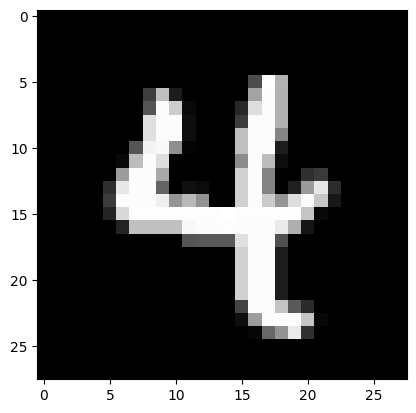

In [5]:
import matplotlib.pyplot as plt

img = xtest[0].squeeze().cpu().numpy()
print(img.shape)
plt.imshow(img, cmap="gray")
plt.show()

接下来请你选择5个你喜欢的数字（60000以下），然后取出训练集中对应位置的图片，并画出它们的内容。

C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


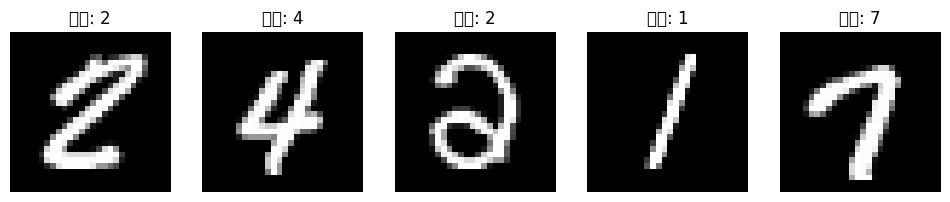

In [6]:
selected_indices = [3, 42, 1000, 8888, 55555]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, idx in zip(axes, selected_indices):
    ax.imshow(x[idx].squeeze().cpu().numpy(), cmap="gray")
    ax.set_title(f"标签: {y[idx].item()}")
    ax.axis("off")
plt.show()

### 1.4 定义模型结构

我们搭建一个类似于 LeNet-5 的网络，结构如下：

![](https://pic1.zhimg.com/80/v2-82eabb4c17e90d467197d013f7629f3c_720w.jpg)

我们需要创建2个卷积层、2个汇聚层和2个全连接层，**暂时忽略所有的激活函数**。所有隐藏层的函数细节都可以在[官方文档](https://pytorch.org/docs/stable/nn.html)中按分类找到。每一个隐藏层本质上都是将一个数组变换成另一个数组的函数，因此为了确认编写的模型是正确的，可以先用一个小数据进行测试，观察输入和输出的维度。例如，我们先取出前6个观测，此时输入的维度是 `[6, 1, 28, 28]`：

In [7]:
ns = 6
smallx = x[0:ns]
smally = y[0:ns]
print(smallx.shape)
print(smally.shape)

torch.Size([6, 1, 28, 28])
torch.Size([6])


接下来创建第1个卷积层，并测试输出的维度。注意到我们可以直接将隐藏层当成一个函数来调用。

In [8]:
conv1 = torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
res1 = conv1(smallx)
print(res1.shape)

torch.Size([6, 20, 24, 24])


可以看到，输出的维度为 `[20, 24, 24]`（不包括第1位的数据批次维度），与之前图中的结果吻合。

接下来，请按照图中提示编写层对象 `pool1`、`conv2`、`pool2`、`fc1` 和 `fc2`，并顺次测试输入与输出的维度，使其与上图匹配。注意，在将一个大小为 `[6, 50, 4, 4]` 的数组（假设叫 `somearray`）传递给 `fc1` 之前，需要先将其变形为只有两个维度的数组，做法是 `somearray.view(-1, 50 * 4 * 4)`，其中 -1 表示该位置的大小不变。也可以使用 `torch.flatten()` 函数并指定其中的 `start_dim` 参数（请搜索其对应的函数文档）。

```py
pool1 = ...
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = ...
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = ...
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = ...
res5 = fc1(res4.view(-1, 800))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = ...
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"
```

In [9]:
pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = torch.nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, stride=1)
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = torch.nn.Linear(50 * 4 * 4, 500)
res5 = fc1(res4.view(-1, 800))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = torch.nn.Linear(500, 10)
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"

torch.Size([6, 20, 12, 12])
torch.Size([6, 50, 8, 8])
torch.Size([6, 50, 4, 4])
torch.Size([6, 500])
torch.Size([6, 10])


### 1.5 创建模型类

在确保隐藏层维度都正确后，将所有的隐藏层封装到一个模型类中，其中模型结构在 `__init__()` 中定义，具体的计算过程在 `forward()` 中实现。此时需要加入激活函数。在本模型中，**请在 `conv1`、`conv2` 和 `fc1` 后加入 ReLU 激活函数，并在 `fc2` 后加入 Softmax 激活函数**。

```py
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ...
        self.pool1 = ...
        self.conv2 = ...
        self.pool2 = ...
        self.fc1 = ...
        self.fc2 = ...

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        ...
        return x
```

In [10]:
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(1, 20, kernel_size=5, stride=1)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = torch.nn.Conv2d(20, 50, kernel_size=5, stride=1)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(50 * 4 * 4, 500)
        self.fc2 = torch.nn.Linear(500, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = x.view(-1, 50 * 4 * 4)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.softmax(x, dim=1)
        return x

再次测试输入输出的维度是否正确。如果模型编写正确，输出的维度应该是 `[6, 10]`，且输出结果为0到1之间的概率值。

In [11]:
np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
pred = model(smallx)
print(pred.shape)
print()
print(pred)
print()
print(torch.sum(pred, dim=1))

torch.Size([6, 10])

tensor([[0.0975, 0.1003, 0.0987, 0.1080, 0.0927, 0.0913, 0.0983, 0.1060, 0.1013,
         0.1058],
        [0.0971, 0.1000, 0.1006, 0.1078, 0.0939, 0.0914, 0.1014, 0.1017, 0.1025,
         0.1037],
        [0.0958, 0.0996, 0.0984, 0.1092, 0.0932, 0.0923, 0.0984, 0.1066, 0.1022,
         0.1043],
        [0.0991, 0.1006, 0.0990, 0.1091, 0.0918, 0.0889, 0.0989, 0.1061, 0.1042,
         0.1021],
        [0.0954, 0.1004, 0.1015, 0.1071, 0.0943, 0.0922, 0.1017, 0.1023, 0.1027,
         0.1024],
        [0.0962, 0.1011, 0.0987, 0.1094, 0.0923, 0.0906, 0.0958, 0.1088, 0.1024,
         0.1048]], grad_fn=<SoftmaxBackward0>)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


`pred` 的每一行加总为1，其中每一个元素代表对应类别的预测概率。

我们还可以直接打印模型对象，观察隐藏层的结构：

In [12]:
print(model)

MyModel(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)


### 1.6 定义损失函数

对于分类问题，损失函数通常选取为负对数似然函数。在 PyTorch 中，可以使用 `torch.nn.NLLLoss` 来完成计算。其用法是先定义一个损失函数对象，然后在预测值和真实标签上调用该函数对象。注意：损失函数对象的第一个参数是预测概率的**对数值**，第二个参数是真实的标签。[文档说明](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)。

In [13]:
lossfn = torch.nn.NLLLoss()
lossfn(torch.log(pred), smally)

tensor(2.3102, grad_fn=<NllLossBackward0>)

### 1.7 编写训练循环

对于本数据，选取 mini-batch 大小为200，共遍历数据3遍，优化器选为 SGD，学习率为0.001。记录每个 mini-batch 下的损失函数值存放到列表 `losses_sgd` 中，然后画出损失函数的曲线。

In [14]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_sgd = []

lossfn = torch.nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
loader_train = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)

for epoch in range(nepoch):
    for bx, by in loader_train:
        pred = model(bx)
        loss = lossfn(torch.log(pred.clamp(min=1e-9)), by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses_sgd.append(loss.item())
    print(f"Epoch {epoch+1}/{nepoch}  loss={losses_sgd[-1]:.4f}")

Epoch 1/3  loss=2.2946
Epoch 2/3  loss=2.2762
Epoch 3/3  loss=2.2685


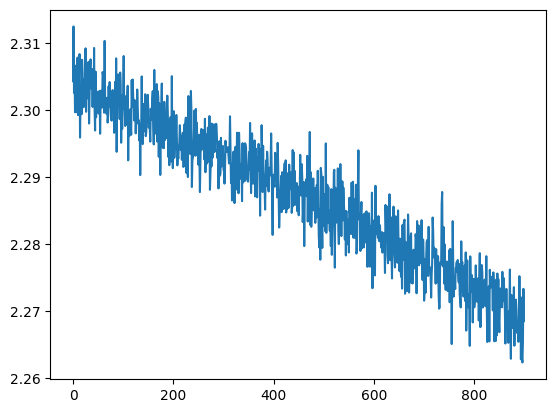

In [15]:
plt.plot(losses_sgd)

接下来使用 Adagrad 优化器（在[官方文档](https://pytorch.org/docs/stable/optim.html)中找到对应的函数），其他参数保持不变，重新训练一次模型，也保存下来损失函数值。

In [16]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_adagrad = []

optimizer = torch.optim.Adagrad(model.parameters(), lr=lr)
loader_train = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)

for epoch in range(nepoch):
    for bx, by in loader_train:
        pred = model(bx)
        loss = lossfn(torch.log(pred.clamp(min=1e-9)), by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses_adagrad.append(loss.item())
    print(f"Epoch {epoch+1}/{nepoch}  loss={losses_adagrad[-1]:.4f}")

Epoch 1/3  loss=0.3162
Epoch 2/3  loss=0.1511
Epoch 3/3  loss=0.1693


对比 SGD 和 Adagrad，画出各自的损失函数曲线。

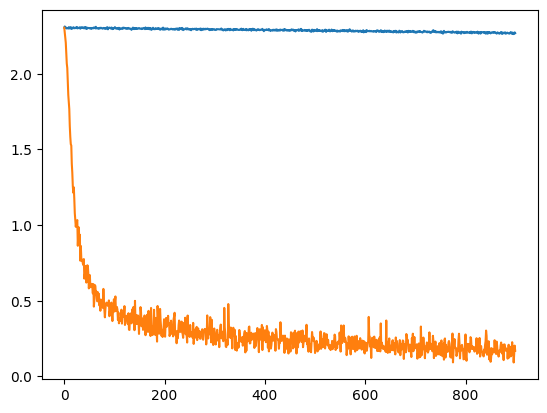

In [17]:
plt.plot(losses_sgd)
plt.plot(losses_adagrad)

最后再自行选择一款优化器，重复上面的实验，并画出三种优化器的损失函数值对比图。

Epoch 1/3  loss=0.1268
Epoch 2/3  loss=0.0115
Epoch 3/3  loss=0.0295


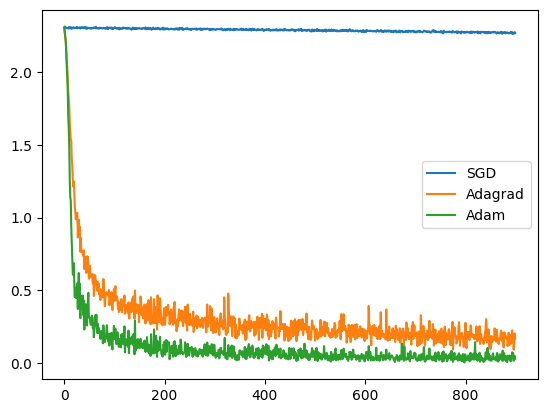

In [18]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_adam = []

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loader_train = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)

for epoch in range(nepoch):
    for bx, by in loader_train:
        pred = model(bx)
        loss = lossfn(torch.log(pred.clamp(min=1e-9)), by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses_adam.append(loss.item())
    print(f"Epoch {epoch+1}/{nepoch}  loss={losses_adam[-1]:.4f}")

plt.plot(losses_sgd, label="SGD")
plt.plot(losses_adagrad, label="Adagrad")
plt.plot(losses_adam, label="Adam")
plt.legend()
plt.show()

### 1.8 实施预测

为了验证模型的效果，我们对10个测试观测（即之前生成的 `testx`）进行预测。

In [19]:
ypred = model(xtest)
print(np.round(ypred.detach().cpu().numpy(), 3))
print(ytest)

[[0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.999 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.999 0.    0.001]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.    0.    0.   ]]
tensor([4, 1, 2, 7, 6, 0, 3, 7, 4, 6])


如果模型搭建和训练都正常，那么每一行中概率最大的取值所在的位置应该正好对应真实的标签。我们也可以让 PyTorch 自动找到最大值的位置。

In [20]:
torch.argmax(ypred, dim=1)

tensor([4, 1, 2, 7, 6, 0, 3, 7, 4, 6])

最后，我们用模型对一些真实的手写数字图片进行预测。请你利用绘图软件（如 Windows 自带的绘图，或 Photoshop 等）准备10张正方形黑色底色的图片，每张用鼠标绘制一个数字（**请使用较粗的笔划**），从0到9，然后以0.png，1.png等文件名存储下来，放到当前目录一个名为 digits 的文件夹中。以下是几个例子：
![](digits/sample0.png) ![](digits/sample5.png) ![](digits/sample8.png)

接下来利用 Pillow 软件包读取图片：

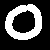

In [21]:
from PIL import Image
im = Image.open("digits/sample0.png")
im

此时如果直接将其转为 Numpy 数组会得到三个或四个通道（可能有一个透明度通道）：

In [22]:
im_arr = np.array(im)
print(im_arr.shape)

(50, 50, 4)


因此，我们先强制转换为灰度图片（单通道），再缩放至模型的图片大小 28 x 28：

In [23]:
im = im.convert("L")
im.thumbnail((28, 28))
im_arr = np.array(im)
print(im_arr.shape)
im

(28, 28)


为了传递给模型对象，还需要先将数值归一化到 [0,1] 区间，转换为 PyTorch 的 Tensor 类型，并增加一个批次和一个通道的维度：

In [24]:
test0 = torch.tensor(im_arr / 255.0, dtype=torch.float32).view(1, 1, 28, 28)
print(test0.shape)

torch.Size([1, 1, 28, 28])


最后对图片标签进行预测：

In [25]:
pred0 = model(test0)
print(np.round(pred0.detach().cpu().numpy(), 3))

[[0.997 0.    0.    0.    0.    0.    0.    0.    0.    0.003]]


预测结果是否符合真实情形？请对你自己绘制出的10张图片进行类似的预测操作，并评价其效果。

**关于自己绘制 10 张手写数字图片的预测**

这一步需要自己手写 0 到 9 一共 10 张图片，因为现在设备不太方便（没有合适的绘图/手写设备），暂时没能自己画图来做这部分。上面用示例图片 sample0.png 已经把读图、转灰度、缩放到 28×28、归一化、再送进模型预测的整个流程跑通了；之后设备方便了，把自己画的 0.png 到 9.png 放进 digits 文件夹，用同样的方法就能预测。

## 2. 循环神经网络

以 `names.txt` 中的英文名作为训练集，利用 RNN 或 LSTM 等方法对字母序列数据进行建模，每个字母视为序列中的一个元素，然后使用拟合的模型随机生成50个名字。本练习为开放式，不指定各类超参数（如网络结构、学习率、迭代次数等），但需提供必要的输出和诊断结果支持你的选择（如模型是否收敛、效果评价等）。

总名字数: 29717，抽样训练: 6000
Epoch  1/20  loss=2.7944
Epoch  2/20  loss=2.4965
Epoch  3/20  loss=2.4073
Epoch  4/20  loss=2.3562
Epoch  5/20  loss=2.3176
Epoch  6/20  loss=2.2831
Epoch  7/20  loss=2.2517
Epoch  8/20  loss=2.2230
Epoch  9/20  loss=2.1920
Epoch 10/20  loss=2.1662
Epoch 11/20  loss=2.1402
Epoch 12/20  loss=2.1142
Epoch 13/20  loss=2.0859
Epoch 14/20  loss=2.0639
Epoch 15/20  loss=2.0359
Epoch 16/20  loss=2.0093
Epoch 17/20  loss=1.9856
Epoch 18/20  loss=1.9620
Epoch 19/20  loss=1.9372
Epoch 20/20  loss=1.9115


C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


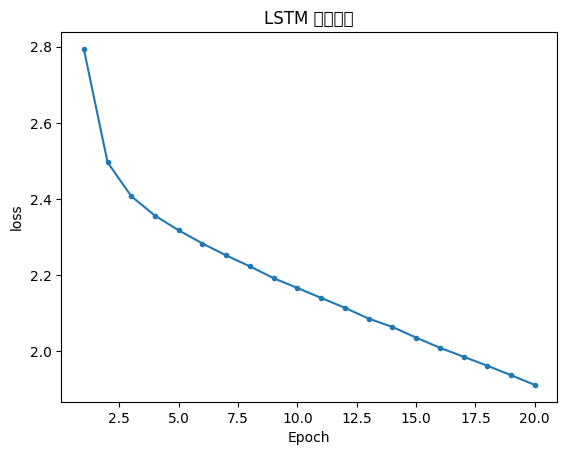


LSTM 生成的 50 个名字:
Tola        Perillo     Julanie     Harsi       Cose        
Bautreman   Femira      Kman        Sham        Leann       
Rosser      Phart       Mooley      Delcore     Bergh       
Sealew      Carse       Freisa      Quett       Sov         
Chart       Perria      Labritce    Jucker      Luit        
Nejo        Jamson      Mather      Protti      Gata        
Houtz       Kinn        Benile      Tarina      Curlick     
Mcpall      Calley      Solt        Leicer      Jone        
Rahil       Amee        Lington     Arren       Avster      
Ratcellan   Pruat       Morrit      Makie       Holliton    


In [26]:
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

# 读取名字，随机抽取 6000 个用于训练
with open("names.txt", encoding="utf-8") as f:
    all_names = [w.strip().lower() for w in f if w.strip()]
rng = np.random.default_rng(42)
names = list(rng.choice(all_names, size=6000, replace=False))
print(f"总名字数: {len(all_names)}，抽样训练: {len(names)}")

# 构建字符表，加入 PAD/SOS/EOS 三个特殊标记
chars = sorted(set("".join(names)))
vocab = ["<PAD>", "<SOS>", "<EOS>"] + chars
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(vocab)
PAD_IDX, SOS_IDX, EOS_IDX = 0, 1, 2

# 编码并补齐到等长，用前一个字符预测下一个字符
def encode(name):
    return [SOS_IDX] + [char2idx[c] for c in name] + [EOS_IDX]

seqs = [encode(n) for n in names]
max_len = max(len(s) for s in seqs)
padded = torch.tensor([s + [PAD_IDX] * (max_len - len(s)) for s in seqs])
inputs, targets = padded[:, :-1], padded[:, 1:]
loader_names = DataLoader(TensorDataset(inputs, targets), batch_size=128, shuffle=True)


class RNNNameModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=48, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(self.embedding(x), hidden)
        return self.fc(out), hidden


rnn_model = RNNNameModel(vocab_size)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.003)

EPOCHS = 20
rnn_losses = []
rnn_model.train()
for epoch in range(EPOCHS):
    total = 0.0
    for bx, by in loader_names:
        optimizer.zero_grad()
        logits, _ = rnn_model(bx)
        loss = criterion(logits.reshape(-1, vocab_size), by.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(rnn_model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    rnn_losses.append(total / len(loader_names))
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  loss={rnn_losses[-1]:.4f}")

# 画损失曲线，观察是否收敛
plt.plot(range(1, EPOCHS + 1), rnn_losses, marker="o", markersize=3)
plt.title("LSTM 训练损失")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()


def generate_rnn(model, temperature=0.8, max_steps=20):
    model.eval()
    with torch.no_grad():
        inp, hidden, out = torch.tensor([[SOS_IDX]]), None, []
        for _ in range(max_steps):
            logits, hidden = model(inp, hidden)
            probs = torch.softmax(logits[0, -1] / temperature, dim=0)
            nxt = torch.multinomial(probs, 1).item()
            if nxt == EOS_IDX:
                break
            if nxt not in (PAD_IDX, SOS_IDX):
                out.append(idx2char[nxt])
            inp = torch.tensor([[nxt]])
    return "".join(out).capitalize()


torch.manual_seed(0)
rnn_names = [generate_rnn(rnn_model) for _ in range(50)]
print("\nLSTM 生成的 50 个名字:")
for i, n in enumerate(rnn_names):
    print(f"{n:<12}", end="" if (i + 1) % 5 else "\n")

## 3. Transformer

利用 Transformer 类型的网络架构，同样对 `names.txt` 中的英文名进行序列建模和训练，再使用拟合的模型随机生成50个名字。

C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_74720\1953419842.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers)


Epoch  1/25  loss=2.8078
Epoch  2/25  loss=2.4939
Epoch  3/25  loss=2.4409
Epoch  4/25  loss=2.4077
Epoch  5/25  loss=2.3817
Epoch  6/25  loss=2.3645
Epoch  7/25  loss=2.3535
Epoch  8/25  loss=2.3354
Epoch  9/25  loss=2.3248
Epoch 10/25  loss=2.3142
Epoch 11/25  loss=2.3038
Epoch 12/25  loss=2.2969
Epoch 13/25  loss=2.2871
Epoch 14/25  loss=2.2792
Epoch 15/25  loss=2.2746
Epoch 16/25  loss=2.2679
Epoch 17/25  loss=2.2613
Epoch 18/25  loss=2.2504
Epoch 19/25  loss=2.2462
Epoch 20/25  loss=2.2415
Epoch 21/25  loss=2.2382
Epoch 22/25  loss=2.2293
Epoch 23/25  loss=2.2250
Epoch 24/25  loss=2.2173
Epoch 25/25  loss=2.2140


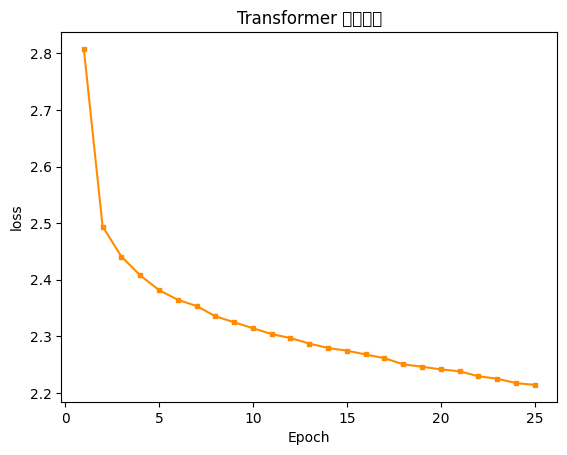


Transformer 生成的 50 个名字:
Tola        Parila      Nincal      Sustre      Schad       
Sautan      Cispeman    Vaman       Shick       Laan        
Rossen      Pharis      Sooke       Delt        Frid        
            Ganis       Zhwar       Frist       Bisan       
Desk        Sodell      Mcgillan    Kiebert     Njiss       
Canis       Auna        Kante       Shem        Theri       
Roe         Kenn        Aman        Bark        Aude        
Caper       Durnel      Uchlard     Canle       Calley      
Sowtre      Hack        Jonres      Hull        Peell       
Wittler     Schustson   Deatre      Anne        Flann       


In [27]:
np.random.seed(42)
torch.manual_seed(42)


class TransformerNameModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_ff=128, pos_len=40):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(pos_len, d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout=0.1,
                                           batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x, pad_mask=None):
        T = x.size(1)
        pos = torch.arange(T).unsqueeze(0)
        h = self.token_emb(x) + self.pos_emb(pos)
        # 因果掩码，禁止关注后面还没生成的字符
        causal = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        h = self.transformer(h, mask=causal, src_key_padding_mask=pad_mask)
        return self.fc(h)


trans_model = TransformerNameModel(vocab_size)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(trans_model.parameters(), lr=0.001,
                             betas=(0.9, 0.98), eps=1e-9)

EPOCHS = 25
trans_losses = []
trans_model.train()
for epoch in range(EPOCHS):
    total = 0.0
    for bx, by in loader_names:
        optimizer.zero_grad()
        logits = trans_model(bx, pad_mask=(bx == PAD_IDX))
        loss = criterion(logits.reshape(-1, vocab_size), by.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(trans_model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    trans_losses.append(total / len(loader_names))
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  loss={trans_losses[-1]:.4f}")

plt.plot(range(1, EPOCHS + 1), trans_losses, marker="s", markersize=3, color="darkorange")
plt.title("Transformer 训练损失")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()


def generate_trans(model, temperature=0.8, max_steps=20):
    model.eval()
    with torch.no_grad():
        seq = [SOS_IDX]
        for _ in range(max_steps):
            logits = model(torch.tensor([seq]))
            probs = torch.softmax(logits[0, -1] / temperature, dim=0)
            nxt = torch.multinomial(probs, 1).item()
            if nxt == EOS_IDX:
                break
            seq.append(nxt)
    return "".join(idx2char[i] for i in seq[1:]
                   if i not in (PAD_IDX, SOS_IDX, EOS_IDX)).capitalize()


torch.manual_seed(0)
trans_names = [generate_trans(trans_model) for _ in range(50)]
print("\nTransformer 生成的 50 个名字:")
for i, n in enumerate(trans_names):
    print(f"{n:<12}", end="" if (i + 1) % 5 else "\n")

## 4. AI 辅助编程工具实战

利用 OpenCode、Claude Code 等 AI 辅助编程工具完成一个小项目的实践，建议贴近日常生活，发挥自己的创意，如编写一个 HTML 小游戏、制作一份个人简历等，主题不限。请把你完成项目的过程录制成一段视频，重点体现你和 Coding Agent 的交互，完成后将视频文件传到 Canvas 中进行提交。

### 第 4 题：AI 辅助编程项目说明（用文字描述代替视频）

我用 AI 辅助编程做的项目是一个本地日程管理小应用 Daily Plan，代码放在 GitHub 上：https://github.com/yanjunlin828-dotcom/Daily_Plan

这个项目是一个跑在本地、不联网的日程工具，数据都存在自己电脑上，主要用来把长期目标拆成每天的任务去完成。功能大概有：把目标拖到当天变成任务、给目标设截止日期和计时、当天没做完的任务自动顺延到第二天、记录每天的工作量并在日历里查看，另外还有标签、子任务、每日备忘这些。技术上前端用的是 HTML、CSS、JavaScript，后端用 Python 的 FastAPI，数据存在 SQLite 里。

和 AI 的交互过程大概是这样：我先有一个想做本地日程工具的想法，把需求用大白话讲给 AI，然后和它一起讨论该怎么设计、用什么技术，最后定下来前后端分离加 FastAPI、SQLite 这套方案。方案定了以后，再让它帮我把项目结构和要做的步骤理出来，分成几个阶段来写。每写完一个阶段我都会自己看一遍代码、把程序跑起来测一下，确认没问题再继续下一个阶段。再往后就是一边自己用一边发现问题，反复让 AI 帮我改功能、修 bug，一点点改到现在能正常用的样子。

整个过程里需求是我自己定的，方案怎么选、每个阶段测得对不对也是我自己把关，AI 主要是帮我出设计建议、写代码和帮忙调试。